In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib as mpl

import scipy
import numpy as np
import ipywidgets as widgets

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [2]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [18]:
GRID_SIZE = 25
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_RECEIVED_AT_RN = 1
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10

FS = 250000
ASSUMED_BAT_SPEED = 4 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)

In [19]:
TIMESTEPS = np.arange(0, ((BAT_INIT_DIST / 2)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
def simulate_N_receivers(time_step, spacing):
    N = 5
    rN_x = np.array([0, 0, 1, 0, 0]) * spacing
    rN_y = np.array([0, 1, 0, -1, 0]) * spacing
    rN_z = np.array([1, 0, 0, 0, -1]) * spacing
    trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = FS
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.02
    signal_duration = 0.1

    time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS)
    y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST / 2)
    z_arr = np.zeros(TIMESTEPS.size)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = 0

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 2], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    map_ax = plt.subplot(gs[0, 1], projection='3d')
    map_ax.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_timestep[:,:,time_idx]+trace_offsets)
    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_zlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_zlabel("Z (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)

    summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_timestep), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_timestep[:, time_idx]
    vrms_summed_fixed = vrms_summed[time_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

time_slider = widgets.FloatSlider(
    value=0, min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Time (k)', layout=Layout(width='1000px'), max=1.3, s…

In [20]:
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
UBNA_ARRAY_MIC_LOCS =  (254/10000) * np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])
UBNA_ARRAY_MIC_LOCS

array([[-0.44958  , -0.9525   ,  0.8048625],
       [-0.44958  ,  0.9525   ,  0.8048625],
       [-0.44958  , -0.9525   ,  0.       ],
       [-0.44958  ,  0.9525   ,  0.       ],
       [-0.44958  , -0.5334   , -0.739775 ],
       [-0.44958  ,  0.5334   , -0.739775 ],
       [ 0.       ,  0.       ,  0.8048625],
       [ 0.       ,  0.       ,  0.       ]])

In [23]:
spacing = 1
N = UBNA_ARRAY_MIC_LOCS.shape[0]
time_step = 0

rN_x = UBNA_ARRAY_MIC_LOCS[:,0] * spacing
rN_y = UBNA_ARRAY_MIC_LOCS[:,1] * spacing
rN_z = UBNA_ARRAY_MIC_LOCS[:,2] * spacing

sampling_rate = FS
t = np.linspace(0, 4, sampling_rate*4)
signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
plot_duration = 0.02
signal_duration = 0.1

time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS)
y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST / 2)
z_arr = np.zeros(TIMESTEPS.size)
pos_x = x_arr[time_idx]
pos_y = y_arr[time_idx]
pos_z = 0

dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
receive_signaln_for_timestep = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)
summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
summed_signal = summed_signal_timestep[:, time_idx]

chunk_of_received_signaln_in_window_timestep.shape

(25000, 8, 14)

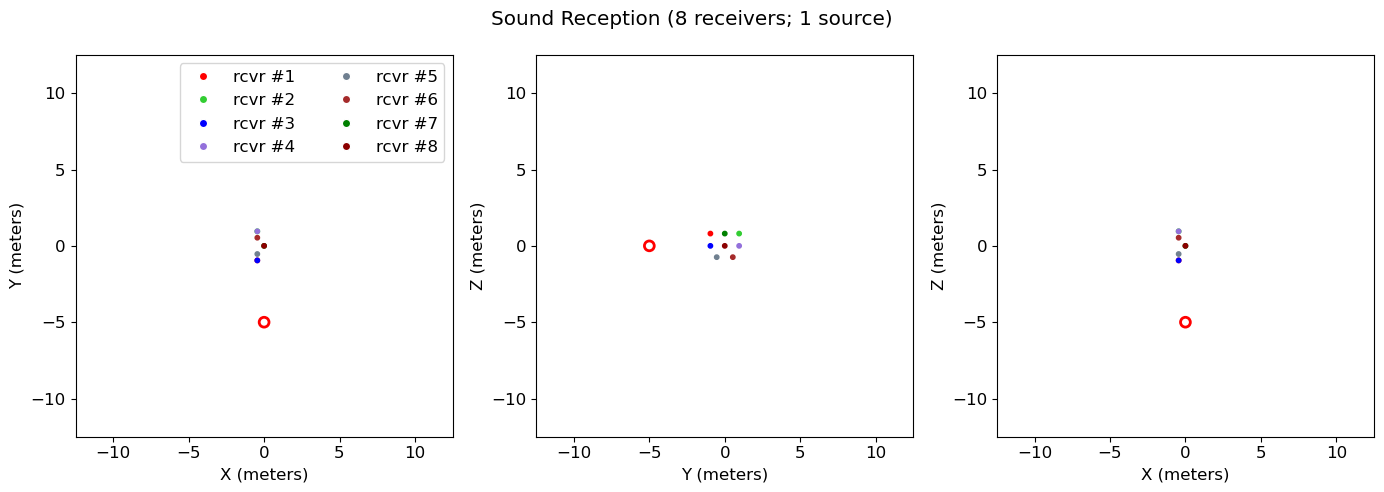

In [24]:
fig, map_ax = plt.subplots(1,3, figsize=(14,5))
top_ax = map_ax[0]
top_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
top_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

top_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
top_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
top_ax.set_xlabel("X (meters)")
top_ax.set_ylabel("Y (meters)")
fig.suptitle(f"Sound Reception ({int(N)} receivers; 1 source)")
top_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

front_ax = map_ax[1]
front_ax.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
front_ax.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

front_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
front_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
front_ax.set_xlabel("Y (meters)")
front_ax.set_ylabel("Z (meters)")
fig.suptitle(f"Sound Reception ({int(N)} receivers; 1 source)")

side_ax = map_ax[2]
side_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
side_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])

side_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
side_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
side_ax.set_xlabel("X (meters)")
side_ax.set_ylabel("Z (meters)")
fig.suptitle(f"Sound Reception ({int(N)} receivers; 1 source)")

fig.tight_layout()
plt.show()

In [28]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 7
microphones_used = np.arange(UBNA_ARRAY_MIC_LOCS.shape[0])+1
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

A_LOCS_MAT = np.array([rN_x,
                       rN_y,
                       rN_z]).T

A_locs_mat_wrt_ref_channel = A_LOCS_MAT
A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(non_ref_microphones_used-1)]

x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

In [29]:
time_received_at_rn = ((np.argmax(chunk_of_received_signaln_in_window_timestep, axis=0)) / sampling_rate).T

In [30]:
t_delay_ref_to_selected_channel = time_received_at_rn[:,ind_of_selected_channel]
time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, ind_of_selected_channel, axis=1)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)
measured_d_mics_to_ref

array([[-0.849268,  1.023512, -0.927472,  0.968632, -0.450016,  0.600936,
         0.064484],
       [-0.786156,  1.05644 , -0.872592,  1.000188, -0.39788 ,  0.63798 ,
         0.069972],
       [-0.703836,  1.086624, -0.79576 ,  1.026256, -0.332024,  0.675024,
         0.074088],
       [-0.59682 ,  1.109948, -0.694232,  1.045464, -0.251076,  0.710696,
         0.080948],
       [-0.465108,  1.120924, -0.565264,  1.053696, -0.156408,  0.739508,
         0.085064],
       [-0.312816,  1.114064, -0.412972,  1.045464, -0.050764,  0.757344,
         0.08918 ],
       [-0.149548,  1.086624, -0.245588,  1.016652,  0.058996,  0.76146 ,
         0.090552],
       [ 0.010976,  1.037232, -0.079576,  0.965888,  0.16464 ,  0.749112,
         0.08918 ],
       [ 0.160524,  0.970004,  0.074088,  0.89866 ,  0.26068 ,  0.721672,
         0.086436],
       [ 0.289492,  0.889056,  0.211288,  0.820456,  0.344372,  0.684628,
         0.08232 ],
       [ 0.39788 ,  0.801248,  0.326536,  0.735392,  0.4116 

In [31]:
time_delay_mics_to_selected_ref_channel

array([[-2.476e-03,  2.984e-03, -2.704e-03,  2.824e-03, -1.312e-03,
         1.752e-03,  1.880e-04,  0.000e+00],
       [-2.292e-03,  3.080e-03, -2.544e-03,  2.916e-03, -1.160e-03,
         1.860e-03,  2.040e-04,  0.000e+00],
       [-2.052e-03,  3.168e-03, -2.320e-03,  2.992e-03, -9.680e-04,
         1.968e-03,  2.160e-04,  0.000e+00],
       [-1.740e-03,  3.236e-03, -2.024e-03,  3.048e-03, -7.320e-04,
         2.072e-03,  2.360e-04,  0.000e+00],
       [-1.356e-03,  3.268e-03, -1.648e-03,  3.072e-03, -4.560e-04,
         2.156e-03,  2.480e-04,  0.000e+00],
       [-9.120e-04,  3.248e-03, -1.204e-03,  3.048e-03, -1.480e-04,
         2.208e-03,  2.600e-04,  0.000e+00],
       [-4.360e-04,  3.168e-03, -7.160e-04,  2.964e-03,  1.720e-04,
         2.220e-03,  2.640e-04,  0.000e+00],
       [ 3.200e-05,  3.024e-03, -2.320e-04,  2.816e-03,  4.800e-04,
         2.184e-03,  2.600e-04,  0.000e+00],
       [ 4.680e-04,  2.828e-03,  2.160e-04,  2.620e-03,  7.600e-04,
         2.104e-03,  2.520e-

In [32]:
true_time_delay_mics_to_selected_ref_channel = ((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR) - (dist_from_source_to_r_n_arr[SELECTED_CHANNEL_FOR_REF,:] / SOUND_SPEED_AIR)).T
true_time_delay_mics_to_selected_ref_channel

array([[-2.47473367e-03,  2.98387543e-03, -2.70439585e-03,
         2.82639586e-03, -1.31278483e-03,  1.75132869e-03,
         1.87656167e-04,  0.00000000e+00],
       [-2.29362363e-03,  3.08201827e-03, -2.54292337e-03,
         2.91475779e-03, -1.15920905e-03,  1.86062839e-03,
         2.02984863e-04,  0.00000000e+00],
       [-2.05255385e-03,  3.16936226e-03, -2.32040436e-03,
         2.99226561e-03, -9.67416767e-04,  1.96976352e-03,
         2.18944333e-04,  0.00000000e+00],
       [-1.74103192e-03,  3.23513208e-03, -2.02382184e-03,
         3.04860459e-03, -7.33140361e-04,  2.07120556e-03,
         2.34601705e-04,  0.00000000e+00],
       [-1.35690898e-03,  3.26568933e-03, -1.64816001e-03,
         3.07075743e-03, -4.57443907e-04,  2.15443467e-03,
         2.48487365e-04,  0.00000000e+00],
       [-9.12709922e-04,  3.24668223e-03, -1.20393790e-03,
         3.04510222e-03, -1.49922518e-04,  2.20725476e-03,
         2.58723363e-04,  0.00000000e+00],
       [-4.36812539e-04,  3.167268

In [33]:
true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, ind_of_selected_channel, axis=1)
true_d_mics_to_ref

array([[-0.84883365,  1.02346927, -0.92760778,  0.96945378, -0.4502852 ,
         0.60070574,  0.06436607],
       [-0.78671291,  1.05713227, -0.87222272,  0.99976192, -0.3976087 ,
         0.63819554,  0.06962381],
       [-0.70402597,  1.08709125, -0.79589869,  1.02634711, -0.33182395,
         0.67562889,  0.07509791],
       [-0.59717395,  1.1096503 , -0.69417089,  1.04567137, -0.25146714,
         0.71042351,  0.08046838],
       [-0.46541978,  1.12013144, -0.56531888,  1.0532698 , -0.15690326,
         0.73897109,  0.08523117],
       [-0.3130595 ,  1.11361201, -0.4129507 ,  1.04447006, -0.05142342,
         0.75708838,  0.08874211],
       [-0.1498267 ,  1.08637296, -0.24680193,  1.0157976 ,  0.05861097,
         0.76112351,  0.09038564],
       [ 0.01175152,  1.03756077, -0.08009046,  0.96657586,  0.16530477,
         0.74938113,  0.08982769],
       [ 0.16065377,  0.96998501,  0.07517865,  0.89966847,  0.26180431,
         0.72296831,  0.08718512],
       [ 0.29032821,  0.8893

In [34]:
measured_d_mics_to_ref

array([[-0.849268,  1.023512, -0.927472,  0.968632, -0.450016,  0.600936,
         0.064484],
       [-0.786156,  1.05644 , -0.872592,  1.000188, -0.39788 ,  0.63798 ,
         0.069972],
       [-0.703836,  1.086624, -0.79576 ,  1.026256, -0.332024,  0.675024,
         0.074088],
       [-0.59682 ,  1.109948, -0.694232,  1.045464, -0.251076,  0.710696,
         0.080948],
       [-0.465108,  1.120924, -0.565264,  1.053696, -0.156408,  0.739508,
         0.085064],
       [-0.312816,  1.114064, -0.412972,  1.045464, -0.050764,  0.757344,
         0.08918 ],
       [-0.149548,  1.086624, -0.245588,  1.016652,  0.058996,  0.76146 ,
         0.090552],
       [ 0.010976,  1.037232, -0.079576,  0.965888,  0.16464 ,  0.749112,
         0.08918 ],
       [ 0.160524,  0.970004,  0.074088,  0.89866 ,  0.26068 ,  0.721672,
         0.086436],
       [ 0.289492,  0.889056,  0.211288,  0.820456,  0.344372,  0.684628,
         0.08232 ],
       [ 0.39788 ,  0.801248,  0.326536,  0.735392,  0.4116 

In [35]:
is_close_matrix_custom = np.isclose(true_d_mics_to_ref, measured_d_mics_to_ref, atol=1e-4)
print("\nComparison with custom tolerance:")
print(is_close_matrix_custom)


Comparison with custom tolerance:
[[False  True False False False False False]
 [False False False False False False False]
 [False False False  True False False False]
 [False False  True False False False False]
 [False False  True False False False False]
 [False False  True False False False False]
 [False False False False False False False]
 [False False False False False False False]
 [False  True False False False False False]
 [False False False False False False False]
 [False False False False  True False False]
 [False False False False False False False]
 [ True False False False False False False]
 [False False False False False False False]]


In [36]:
idx = 11
measured_d_mics_to_ref[idx,:], true_d_mics_to_ref[idx,:]

(array([0.488432, 0.714812, 0.422576, 0.6517  , 0.465108, 0.594076,
        0.072716]),
 array([0.48781726, 0.71451804, 0.42165349, 0.65130079, 0.46541109,
        0.59418637, 0.07234965]))

In [37]:
dm0_column = true_d_mics_to_ref[idx,:].reshape((num_nonref_channels, 1))
A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
A_mat

array([[ 0.44958   ,  0.9525    , -0.8048625 ,  0.48781726],
       [ 0.44958   , -0.9525    , -0.8048625 ,  0.71451804],
       [ 0.44958   ,  0.9525    ,  0.        ,  0.42165349],
       [ 0.44958   , -0.9525    ,  0.        ,  0.65130079],
       [ 0.44958   ,  0.5334    ,  0.739775  ,  0.46541109],
       [ 0.44958   , -0.5334    ,  0.739775  ,  0.59418637],
       [ 0.        ,  0.        , -0.8048625 ,  0.07234965]])

In [38]:
xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))
wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
wm0

array([[-0.75960819],
       [-0.62332302],
       [-0.46579338],
       [-0.34259286],
       [-0.40864865],
       [-0.34042367],
       [-0.32128459]])

In [39]:
np.linalg.cond(A_mat)

75.07974344995463

In [40]:
xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
source_loc = xs.reshape((1,4))
source_loc

array([[ 4.40000000e+00, -6.00000000e-01,  8.84602655e-16,
        -4.44072066e+00]])

In [41]:
lam = 1e-4
ATA = A_mat.T @ A_mat
ATb = A_mat.T @ wm0
ridge_solution = np.linalg.solve(ATA + lam * np.eye(A_mat.shape[1]), ATb)

source_loc = ridge_solution.reshape((1,4))
source_loc

array([[ 3.8460309 , -0.54617322,  0.02509131, -3.99191045]])

In [42]:
dm0_column = measured_d_mics_to_ref[idx,:].reshape((num_nonref_channels, 1))
A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
A_mat

array([[ 0.44958  ,  0.9525   , -0.8048625,  0.488432 ],
       [ 0.44958  , -0.9525   , -0.8048625,  0.714812 ],
       [ 0.44958  ,  0.9525   ,  0.       ,  0.422576 ],
       [ 0.44958  , -0.9525   ,  0.       ,  0.6517   ],
       [ 0.44958  ,  0.5334   ,  0.739775 ,  0.465108 ],
       [ 0.44958  , -0.5334   ,  0.739775 ,  0.594076 ],
       [ 0.       ,  0.       , -0.8048625,  0.072716 ]])

In [43]:
xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))
wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
wm0

array([[-0.75930813],
       [-0.62311294],
       [-0.46540398],
       [-0.34233277],
       [-0.40878967],
       [-0.34048925],
       [-0.32125801]])

In [44]:
np.linalg.cond(A_mat)

75.84449405854602

In [45]:
xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
source_loc = xs.reshape((1,4))
source_loc

array([[ 4.46558186, -0.60526556, -0.00492313, -4.49122707]])

In [46]:
source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
for i in range(measured_d_mics_to_ref.shape[0]):
    dm0_column = measured_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
    A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
        
    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

    xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

    wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

    xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
    source_locs[:,i] = xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
source_locs

array([[-5.20463405e-03,  3.98364498e-01,  8.11353356e-01,
         1.18800796e+00,  1.60080360e+00,  1.99815270e+00,
         2.42624897e+00,  2.83681537e+00,  3.22689452e+00,
         3.63857317e+00,  4.04582907e+00,  4.46558186e+00,
         4.84378865e+00,  5.17614936e+00],
       [-4.96993428e+00, -4.59751583e+00, -4.23474715e+00,
        -3.77484990e+00, -3.39668297e+00, -2.99556950e+00,
        -2.61511821e+00, -2.22011997e+00, -1.81268538e+00,
        -1.41116887e+00, -1.00824002e+00, -6.05265564e-01,
        -2.02070018e-01,  1.98143262e-01],
       [ 1.54862912e-03, -4.79101742e-04, -4.78800060e-04,
         4.57658618e-04,  2.00011983e-04,  7.61053082e-05,
        -1.18857608e-03, -1.42479072e-03, -3.57841015e-03,
        -8.83751911e-04,  6.68084803e-04, -4.92313043e-03,
        -3.77267214e-03,  2.47648183e-03],
       [-4.97036080e+00, -4.61534006e+00, -4.31346995e+00,
        -3.95731323e+00, -3.75234742e+00, -3.59810319e+00,
        -3.56135248e+00, -3.59907502e+00, -3.

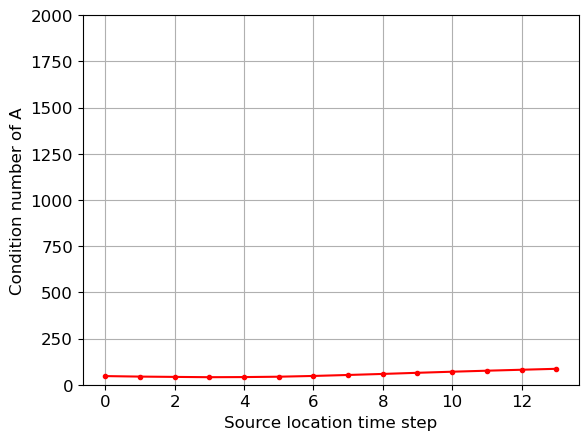

In [47]:
plt.plot(cond_a_vals, marker='.')
plt.grid(which='both')
plt.ylabel('Condition number of A')
plt.xlabel('Source location time step')
plt.ylim(0, 2000)
plt.show()

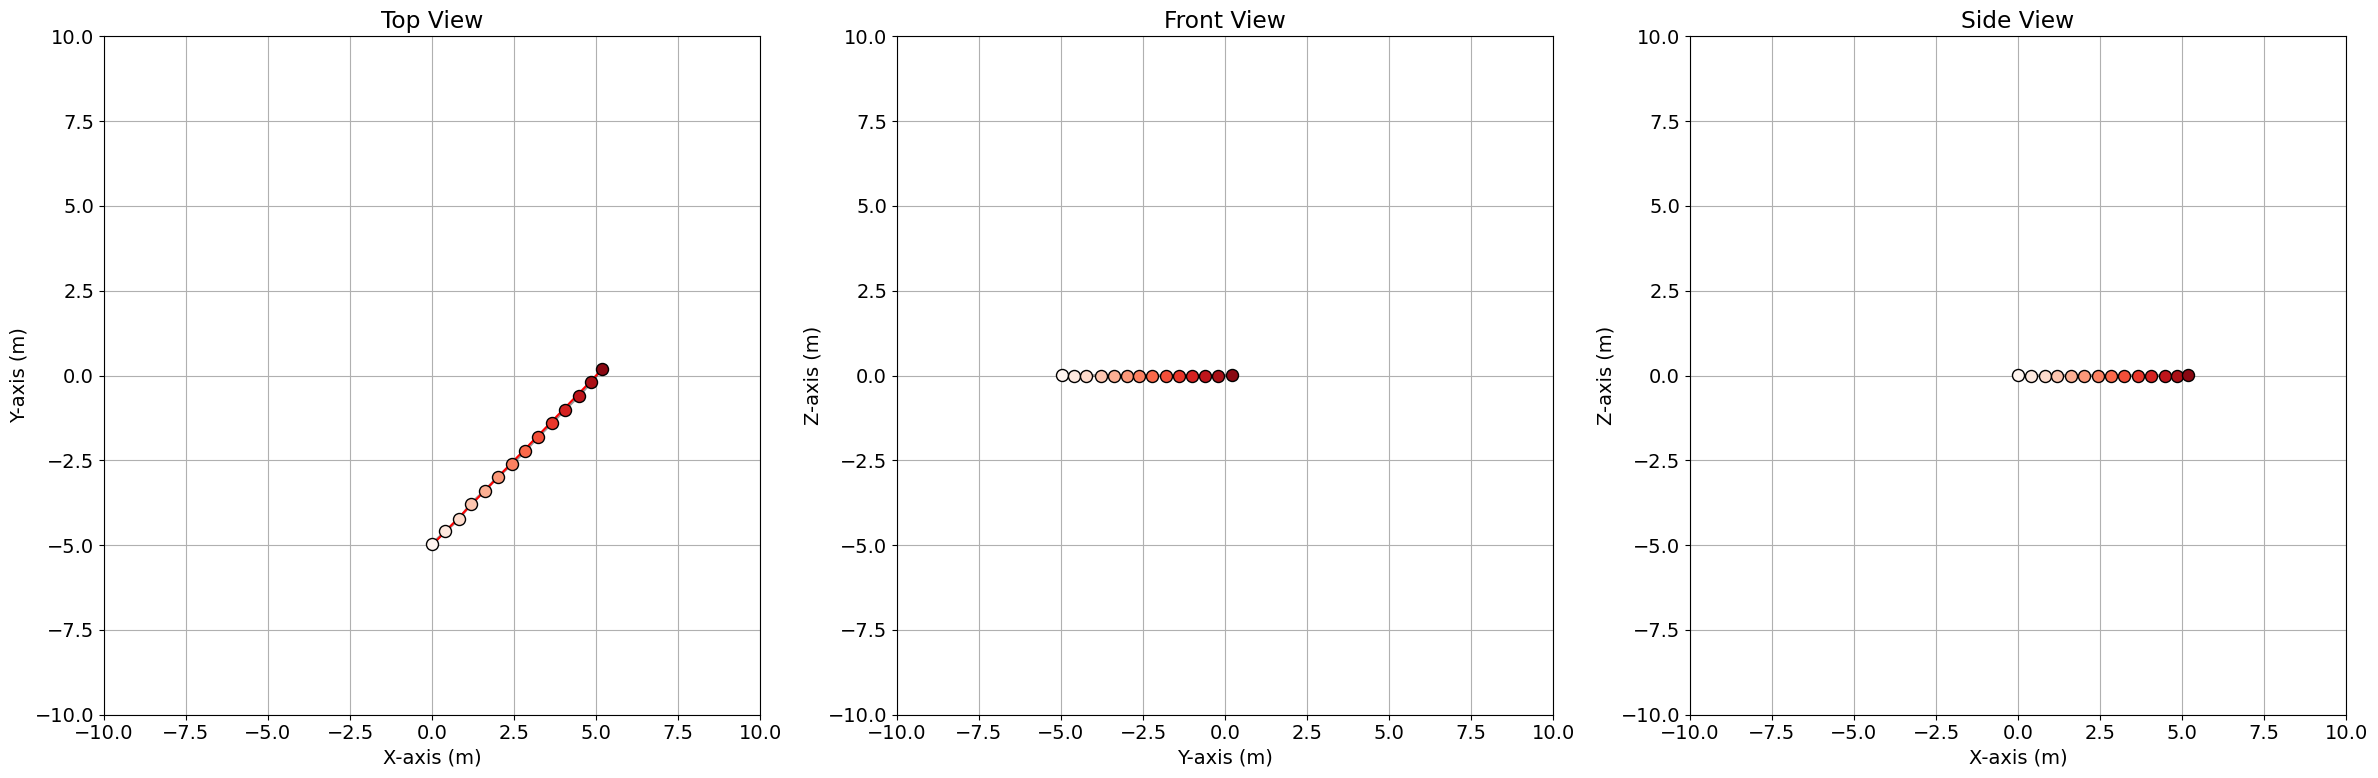

In [51]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':14})
start = 0
end = source_locs.shape[1]

ax1.plot(source_locs[0,start:end], source_locs[1,start:end], alpha=0.4, linewidth=2, color='k')
ax1.plot(x_arr, y_arr, label='true position')

ax2.plot(source_locs[1,start:end], source_locs[2,start:end], alpha=0.4, linewidth=2, color='k')

ax3.plot(source_locs[0,start:end], source_locs[2,start:end], alpha=0.4, linewidth=2, color='k')

norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
for i in range(start, end):
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
    ax1.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax2.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax3.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)

ax1.set_ylim(-10, 10)
ax1.set_xlim(-10, 10)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_ylim(-10, 10)
ax2.set_xlim(-10, 10)
ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_ylim(-10, 10)
ax3.set_xlim(-10, 10)
ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

### Below is now certified to work!!

In [52]:
source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]), dtype=np.float64)
for i in range(true_d_mics_to_ref.shape[0]):
    dm0_column = true_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
    A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
        
    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

    xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

    wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

    xs, residuals, rank, sing_vals = np.linalg.lstsq(A_mat, wm0, rcond=None)

    source_locs[:,i] = xs.reshape((1,4))
source_locs

array([[ 2.12550479e-15,  4.00000000e-01,  8.00000000e-01,
         1.20000000e+00,  1.60000000e+00,  2.00000000e+00,
         2.40000000e+00,  2.80000000e+00,  3.20000000e+00,
         3.60000000e+00,  4.00000000e+00,  4.40000000e+00,
         4.80000000e+00,  5.20000000e+00],
       [-5.00000000e+00, -4.60000000e+00, -4.20000000e+00,
        -3.80000000e+00, -3.40000000e+00, -3.00000000e+00,
        -2.60000000e+00, -2.20000000e+00, -1.80000000e+00,
        -1.40000000e+00, -1.00000000e+00, -6.00000000e-01,
        -2.00000000e-01,  2.00000000e-01],
       [-3.39734716e-15,  2.46093166e-15,  1.09037721e-16,
        -1.25374549e-16,  1.05646441e-16, -8.64367444e-16,
         1.06049757e-16,  1.81879913e-15, -3.21883240e-15,
         2.59349397e-16,  7.69136163e-16,  8.84602655e-16,
        -4.68073581e-15, -2.65989876e-15],
       [-5.00000000e+00, -4.61735855e+00, -4.27551167e+00,
        -3.98497177e+00, -3.75765885e+00, -3.60555128e+00,
        -3.53836120e+00, -3.56089876e+00, -3.

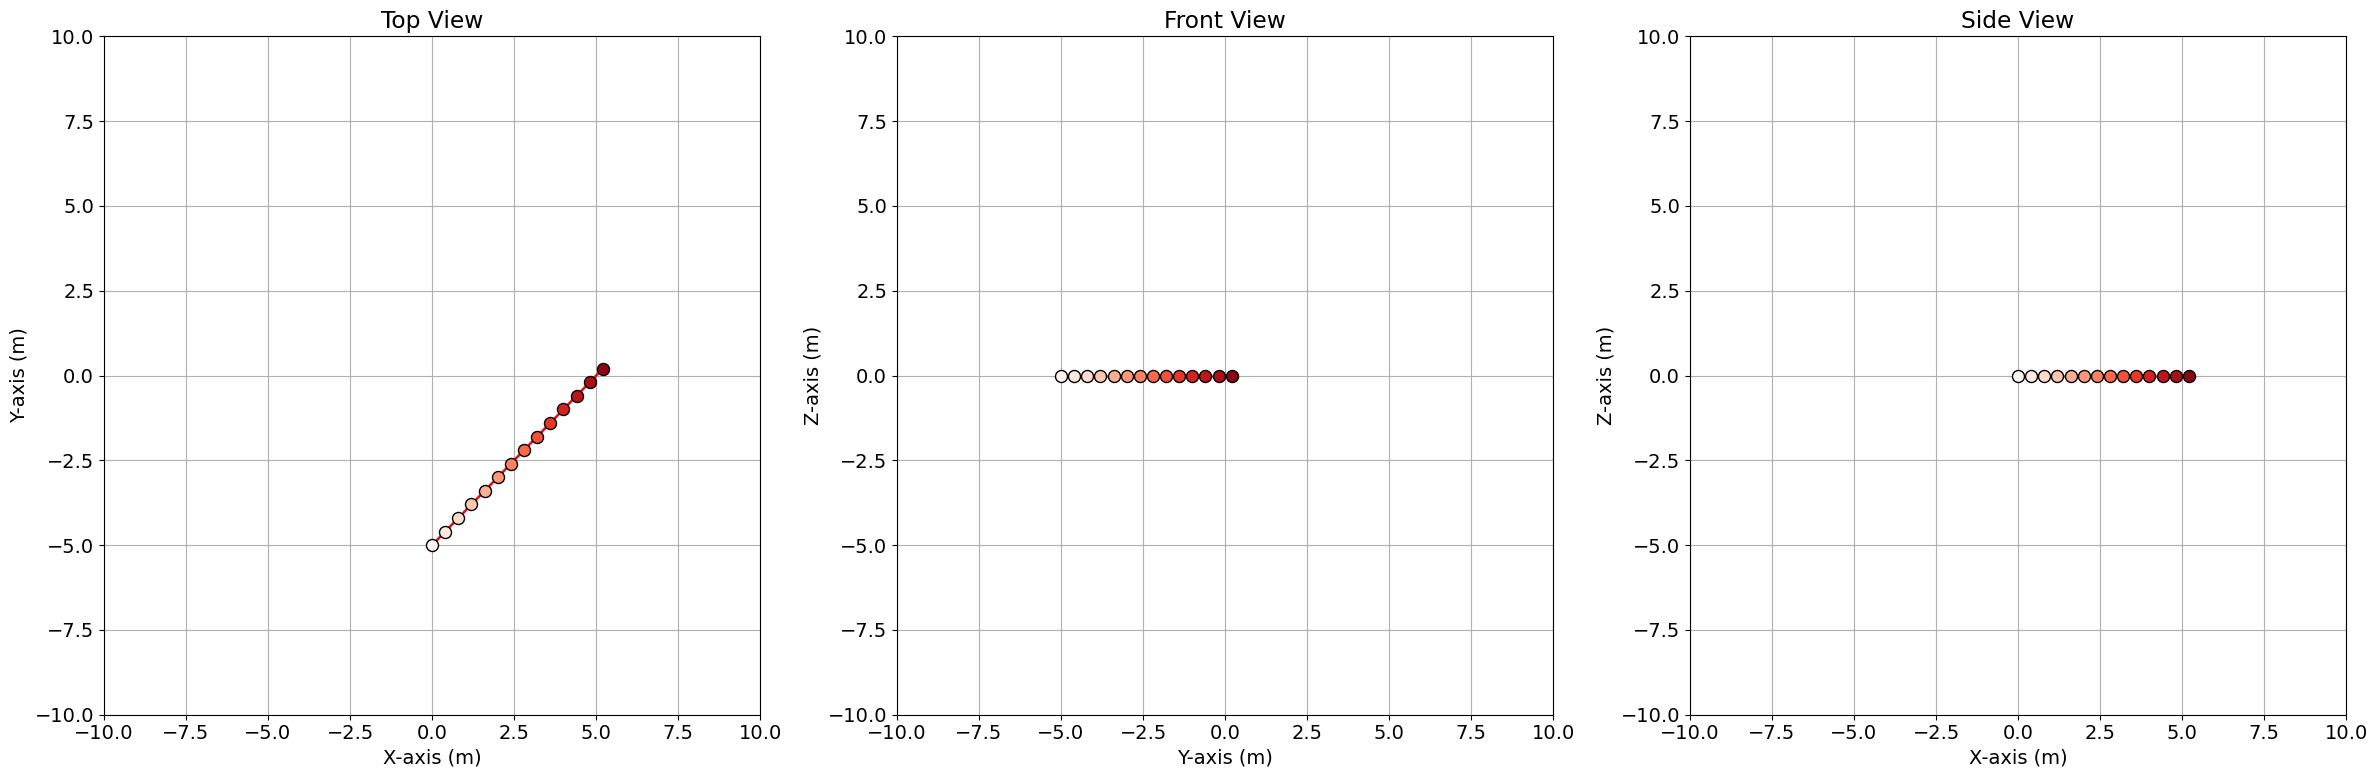

In [53]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':14})

ax1.plot(source_locs[0,:], source_locs[1,:], alpha=0.4, linewidth=2, color='k')
ax1.plot(x_arr, y_arr, label='true position')

ax2.plot(source_locs[1,:], source_locs[2,:], alpha=0.4, linewidth=2, color='k')

ax3.plot(source_locs[0,:], source_locs[2,:], alpha=0.4, linewidth=2, color='k')

norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
for i in range(source_locs.shape[1]):
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
    ax1.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax2.scatter(source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)
    ax3.scatter(source_locs[0,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=2)

ax1.set_ylim(-10, 10)
ax1.set_xlim(-10, 10)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_ylim(-10, 10)
ax2.set_xlim(-10, 10)
ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_ylim(-10, 10)
ax3.set_xlim(-10, 10)
ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

In [ ]:
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
def simulate_N_receivers(time_step, spacing):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0] * spacing
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1] * spacing
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2] * spacing
    trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = FS
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.02
    signal_duration = 0.1

    time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST)
    z_arr = np.zeros(TIMESTEPS.size) + 5
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = 5

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    time_received_at_rn = ((np.argmax(chunk_of_received_signaln_in_window_timestep, axis=0)) / sampling_rate).T
    t_delay_ref_to_selected_channel = time_received_at_rn[:,ind_of_selected_channel]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, ind_of_selected_channel, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    true_time_delay_mics_to_selected_ref_channel = ((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR) - (dist_from_source_to_r_n_arr[SELECTED_CHANNEL_FOR_REF,:] / SOUND_SPEED_AIR)).T
    true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, ind_of_selected_channel, axis=1)

    source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]), dtype=np.float64)
    cond_a_vals = np.zeros(true_d_mics_to_ref.shape[0], dtype=np.float64)
    for i in range(true_d_mics_to_ref.shape[0]):
        dm0_column = true_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
            
        x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
        y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
        z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

        xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
        ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
        zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 2], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
    for i in range(time_idx):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    map_ax = plt.subplot(gs[0, 1], projection='3d')
    map_ax.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
    for i in range(time_idx):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax.scatter(source_locs[0,i], source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_timestep[:,:,time_idx]+trace_offsets)
    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_zlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_zlabel("Z (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)

    summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_timestep), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_timestep[:, time_idx]
    vrms_summed_fixed = vrms_summed[time_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

time_slider = widgets.FloatSlider(
    value=0, min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Time (k)', layout=Layout(width='1000px'), max=5.0, s…

In [ ]:
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
def simulate_N_receivers(time_step, spacing):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0] * spacing
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1] * spacing
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2] * spacing
    trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

    sampling_rate = FS
    t = np.linspace(0, 4, sampling_rate*4)
    signal = scipy.signal.unit_impulse(t.size, idx=TIME_RECEIVED_AT_RN*sampling_rate) * 1000
    plot_duration = 0.02
    signal_duration = 0.1

    time_idx = np.where(np.isclose(TIMESTEPS, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (TIMESTEPS) - (BAT_INIT_DIST)
    z_arr = np.zeros(TIMESTEPS.size) + 5
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = 5

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * sampling_rate))
    rn_indices = ((TIME_RECEIVED_AT_RN - time_to_rn_array) * sampling_rate).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    time_received_at_rn = ((np.argmax(chunk_of_received_signaln_in_window_timestep, axis=0)) / sampling_rate).T
    t_delay_ref_to_selected_channel = time_received_at_rn[:,ind_of_selected_channel]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, ind_of_selected_channel, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]):
        dm0_column = measured_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
            
        x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
        y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
        z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]

        xm = A_locs_mat_tdoa_meters[:,0].reshape((num_nonref_channels, 1))
        ym = A_locs_mat_tdoa_meters[:,1].reshape((num_nonref_channels, 1))
        zm = A_locs_mat_tdoa_meters[:,2].reshape((num_nonref_channels, 1))

        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)

    fig = plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 2], wspace=0.3) 
    gs_signals = gridspec.GridSpecFromSubplotSpec(2, 1, height_ratios=[2,1], subplot_spec=gs[0, 2], hspace=0.8)
    map_ax = plt.subplot(gs[0, 0])
    map_ax.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    line_handles = [Line2D([0], [0], label=f'rcvr #{i+1}', color=COLOR_CYCLE[i]) for i in range(N)]

    norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
    for i in range(time_idx):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax.scatter(source_locs[0,i], source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    # map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    map_ax = plt.subplot(gs[0, 1], projection='3d')
    map_ax.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    received_ax = plt.subplot(gs_signals[0])
    map_ax.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    norm = plt.Normalize(vmin=0, vmax=source_locs.shape[1])
    for i in range(time_idx):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax.scatter(source_locs[0,i], source_locs[1,i], source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    received_ax.plot(1000*(np.tile(signal_duration_samples / sampling_rate, (N, 1)).T), chunk_of_received_signaln_in_window_timestep[:,:,time_idx]+trace_offsets)
    map_ax.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_zlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax.set_xlabel("X (meters)")
    map_ax.set_ylabel("Y (meters)")
    map_ax.set_zlabel("Z (meters)")
    map_ax.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax.legend(handles=marker_handles, ncol=2, loc='upper right')

    received_ax.set_xlabel("Time (ms)")
    received_ax.set_ylabel("Amplitude")
    received_ax.set_title("Received voltage signals")
    received_ax.grid(which='both')
    received_ax.set_yticks([], [])
    received_ax.set_xlim(0, 1000*plot_duration)
    received_ax.set_ylim(-1e-4, 1e-4)

    summed_signal_timestep = np.sum(chunk_of_received_signaln_in_window_timestep, axis=1)
    vrms_summed = np.sqrt(np.mean(np.square(summed_signal_timestep), axis=0))
    vrms_summed_dB = 20*np.log10(vrms_summed)
    vrms_summed_dB_norm = vrms_summed_dB - vrms_summed_dB.max()

    summed_signal = summed_signal_timestep[:, time_idx]
    vrms_summed_fixed = vrms_summed[time_idx]
    vrms_summed_fixed_dB = 20*np.log10(vrms_summed_fixed)
    vrms_summed_fixed_dB_norm = vrms_summed_fixed_dB - vrms_summed_dB.max()

    summed_ax = plt.subplot(gs_signals[1])
    summed_ax.plot(1000*(signal_duration_samples / sampling_rate), summed_signal, 'k')
    summed_ax.set_xlabel("Time (ms)")
    summed_ax.set_ylabel("Amplitude")
    summed_ax.set_title("Summed voltage signal")
    summed_ax.set_yticks([], [])
    summed_ax.grid(which='both')
    summed_ax.set_xlim(0, 1000*plot_duration)
    summed_ax.set_ylim(-5e-5, 5e-5)

    plt.show()

time_slider = widgets.FloatSlider(
    value=0, min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

N_slider = widgets.IntSlider(
    value=0, min=1, max=5, step=1, description="# receivers", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="300px")
)

spacing_slider = widgets.FloatSlider(
    value=1, min=0, max=5, step=0.01, description="Spacing (m)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, N=N_slider, spacing=spacing_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Time (k)', layout=Layout(width='1000px'), max=5.0, s…